In [1]:
import pandas as pd
import numpy as np

fao = pd.read_csv("FAOSTAT_data.csv")
crop = pd.read_csv("Crop_recommendation.csv")

In [2]:
fao

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,5.692710e+05,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,4.303000e+02,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,t,2.449430e+05,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,ha,5.470280e+05,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,kg/ha,2.968000e+02,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [3]:
crop

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [7]:
fao['Item'].unique()[:40]


array(['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Areca nuts', 'Bananas', 'Barley',
       'Beans, dry', 'Cabbages', 'Cantaloupes and other melons',
       'Carrots and turnips', 'Cashew nuts, in shell', 'Cassava, fresh',
       'Castor oil seeds', 'Cauliflowers and broccoli', 'Cherries',
       'Chick peas, dry',
       'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Cocoa beans', 'Coconuts, in shell', 'Coffee, green', 'Coir, raw',
       'Cucumbers and gherkins', 'Eggplants (aubergines)', 'Figs',
       'Ginger, raw', 'Grapes', 'Green garlic',
       'Groundnuts, excluding shelled', 'Jute, raw or retted',
       'Kenaf, and other textile bast fibres, raw or retted',
       'Lemons and limes', 'Lentils, dry', 'Lettuce and chicory',
       'Linseed', 'Maize (corn)', 'Mangoes, guavas and mangosteens',
       'Millet', 'Mushrooms a

In [9]:
for i in fao['Item'].unique():
    print(i)

Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw
Apples
Apricots
Areca nuts
Bananas
Barley
Beans, dry
Cabbages
Cantaloupes and other melons
Carrots and turnips
Cashew nuts, in shell
Cassava, fresh
Castor oil seeds
Cauliflowers and broccoli
Cherries
Chick peas, dry
Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
Cocoa beans
Coconuts, in shell
Coffee, green
Coir, raw
Cucumbers and gherkins
Eggplants (aubergines)
Figs
Ginger, raw
Grapes
Green garlic
Groundnuts, excluding shelled
Jute, raw or retted
Kenaf, and other textile bast fibres, raw or retted
Lemons and limes
Lentils, dry
Lettuce and chicory
Linseed
Maize (corn)
Mangoes, guavas and mangosteens
Millet
Mushrooms and truffles
Natural rubber in primary forms
Nutmeg, mace, cardamoms, raw
Okra
Onions and shallots, dry (excluding dehydrated)
Oranges
Other beans, green
Other berries and fruits of the genus vaccinium n.e.c.
Other citrus fruit,

In [11]:
crop['label'].unique()


array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [13]:
fao['Item'] = fao['Item'].str.split(r",|and")
fao = fao.explode('Item') 

In [15]:
fao

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,Anise,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,badian,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cori,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,er,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cumin,2001,2001,ha,5.692710e+05,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [17]:
#" other melons":"muskmelon",

In [19]:
crop_mapping = {
    "Rice": "rice",
    "Maize (corn)": "maize",
    "Chick peas":"chickpea",
    "Pigeon peas":"pigeonpeas" ,
    "Beans":"mothbeans" ,
    "Lentils":"lentil" ,
    "Bananas":"banana" ,
    "Mangoes": "mango" ,
    "Grapes":"grapes" ,
    "Watermelons":"watermelon" ,
    "Cantaloupes ":"muskmelon",   
    "Apples":"apple" ,
    "Oranges":"orange" ,
    "Papayas":"papaya" ,
    "Coconuts":"coconut" ,
    "Seed cotton":"cotton"  ,
    "Jute":"jute" ,
    "Coffee":"coffee"
    
}





In [21]:
len(crop_mapping)

18

In [23]:
fao['Crop']=fao['Item'].map(crop_mapping)

In [25]:
crop=crop.rename(columns={'label':'Crop'})

In [27]:
crop

,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [29]:
df_merged = crop.merge(
    fao,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

In [31]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,4.490000e+07,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3.115800e+03,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2001,2001,t,1.399000e+08,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2002,2002,ha,4.117610e+07,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2.616300e+03,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,7.742000e+02,E,Estimated value,NaN
124196,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN
124197,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Area harvested,1610.0,Coffee,2023,2023,ha,4.378620e+05,I,Value imputed by a receiving agency,NaN
124198,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2023,2023,kg/ha,7.602000e+02,E,Estimated value,NaN


In [33]:
print(df_merged['Element'].unique())

['Area harvested' 'Yield' 'Production']


In [35]:
df_merged = df_merged[df_merged['Element'] == 'Yield']


In [37]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3115.8,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2616.3,A,Official figure,NaN
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2003,2003,kg/ha,3117.7,A,Official figure,NaN
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2004,2004,kg/ha,2975.6,A,Official figure,NaN
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2005,2005,kg/ha,3153.7,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2019,2019,kg/ha,766.7,A,Official figure,NaN
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2020,2020,kg/ha,712.6,A,Official figure,NaN
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2021,2021,kg/ha,789.7,A,Official figure,NaN
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,774.2,E,Estimated value,NaN


In [39]:
print(df_merged['Element'].unique())

['Yield']


In [41]:
df_merged['Crop'].value_counts()


Crop
rice          2300
maize         2300
jute          2300
cotton        2300
coconut       2300
papaya        2300
orange        2300
apple         2300
muskmelon     2300
watermelon    2300
grapes        2300
mango         2300
banana        2300
lentil        2300
mothbeans     2300
pigeonpeas    2300
chickpea      2300
coffee        2300
Name: count, dtype: int64

In [43]:
df_merged=df_merged.drop(columns=['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item','Year', 'Year Code','Unit', 'Flag', 'Flag Description', 'Note'])

In [45]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


In [48]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


In [50]:
final_df = df_merged.copy()
print("Dataset Shape:", final_df.shape)


Dataset Shape: (41400, 9)


In [52]:
print("Missing values before cleaning:")
print(final_df.isnull().sum())


Missing values before cleaning:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64


In [54]:
final_df['Value'] = pd.to_numeric(final_df['Value'], errors='coerce')


In [56]:
value_mean = final_df['Value'].mean()
final_df['Value'] = final_df['Value'].fillna(value_mean)


In [58]:
noise = np.random.uniform(-500, 500, len(final_df))
final_df['Value'] = final_df['Value'] + noise


In [60]:
final_df['Value'] = final_df['Value'].clip(lower=0)


In [62]:
soil_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [64]:
for col in soil_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
        final_df[col] = final_df[col].fillna(final_df[col].mean())


In [66]:
print("Missing values after cleaning:")
print(final_df.isnull().sum())


Missing values after cleaning:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64


In [68]:
if final_df.isnull().sum().sum() == 0:
    print("Dataset is clean and ready for modeling")
else:
    print(" Some missing values still exist")


Dataset is clean and ready for modeling


In [70]:
final_df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64

In [72]:
final_df.duplicated().sum()  

114

In [74]:
final_df=final_df.drop_duplicates().reset_index(drop=True)

In [76]:
final_df

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2748.734915
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2271.123913
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2960.979166
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2777.587400
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3251.677623
...,...,...,...,...,...,...,...,...,...
41281,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,637.122379
41282,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,892.873807
41283,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,742.830257
41284,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,846.111727


In [78]:
final_df.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,41286.000000,41286.000000,41286.000000,41286.000000,41286.000000,41286.000000,41286.000000,41286.000000
mean,56.288161,54.068837,53.418641,25.720678,72.845716,6.458422,108.290287,10093.740951
std,37.981157,35.053268,54.515359,5.126317,20.775290,0.799599,58.195789,11860.679247
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,0.000000
25%,24.000000,27.000000,22.000000,23.062044,60.474705,6.001936,66.483393,1112.605683
50%,44.000000,49.000000,35.000000,25.612944,80.555572,6.399891,97.312581,4435.100301
75%,91.000000,69.000000,52.000000,28.434307,90.555616,6.896552,145.105065,18049.283991
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,44816.967450


In [80]:
final_df.nunique()

N                136
P                117
K                 73
temperature     1800
humidity        1800
ph              1800
rainfall        1800
Crop              18
Value          41198
dtype: int64

--- Outlier Analysis (Before Removal) ---


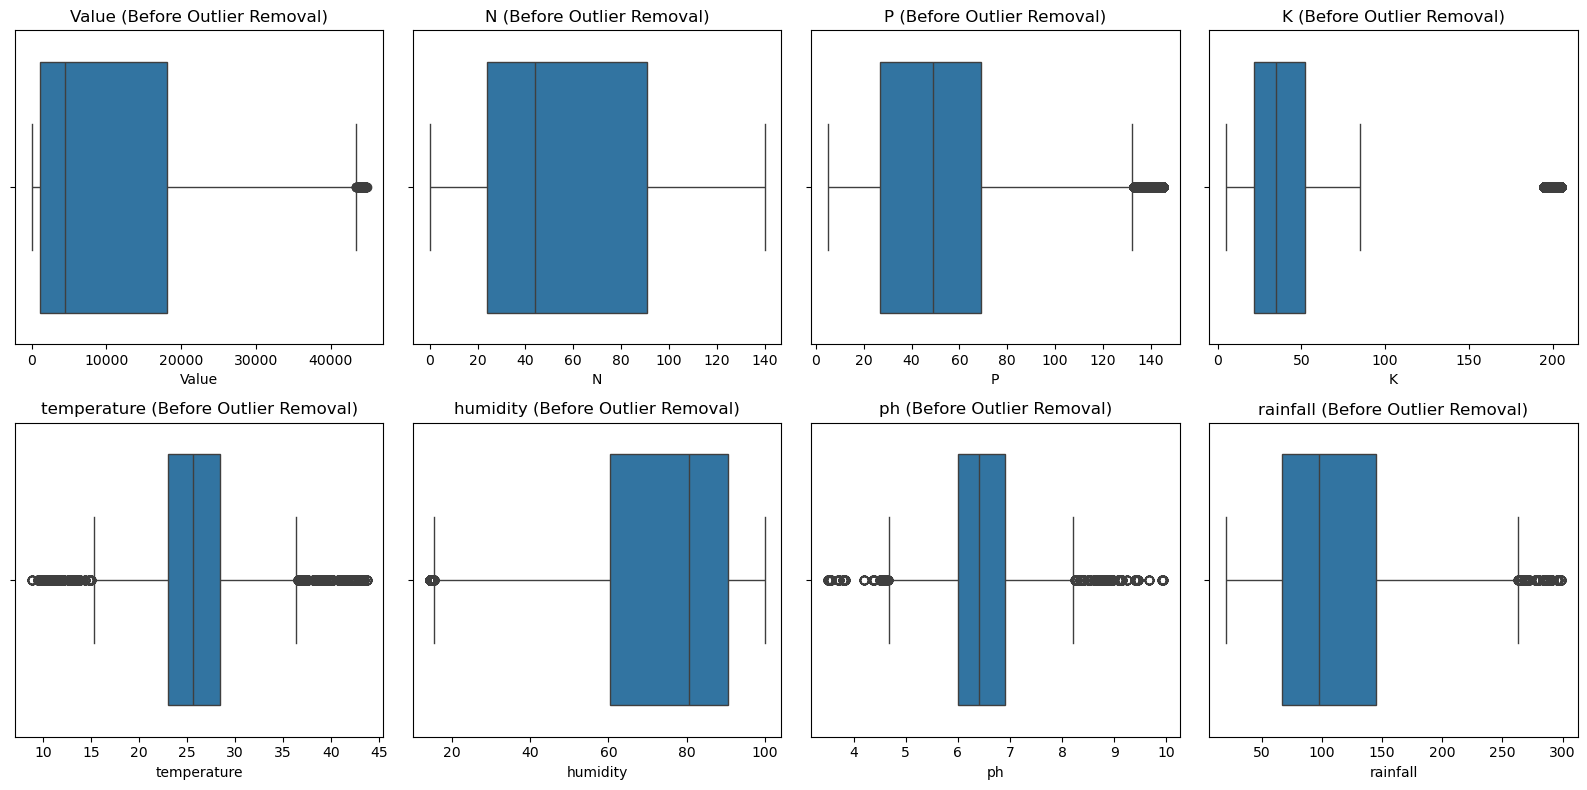

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Outlier Analysis (Before Removal) ---")

# Columns to analyze
numeric_cols = ['Value', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Ensure numeric values
for col in numeric_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

# Drop rows with missing numeric values
final_df = final_df.dropna(subset=numeric_cols)

# Plot boxplots
plt.figure(figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x=final_df[col])
    plt.title(f"{col} (Before Outlier Removal)")

plt.tight_layout()
plt.show()


In [83]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

    return df_clean


In [86]:
print("Shape before outlier removal:", final_df.shape)

final_df = remove_outliers_iqr(final_df, numeric_cols)

print("Shape after outlier removal:", final_df.shape)


Shape before outlier removal: (41286, 9)
Shape after outlier removal: (33407, 9)


--- Outlier Analysis (After Removal) ---


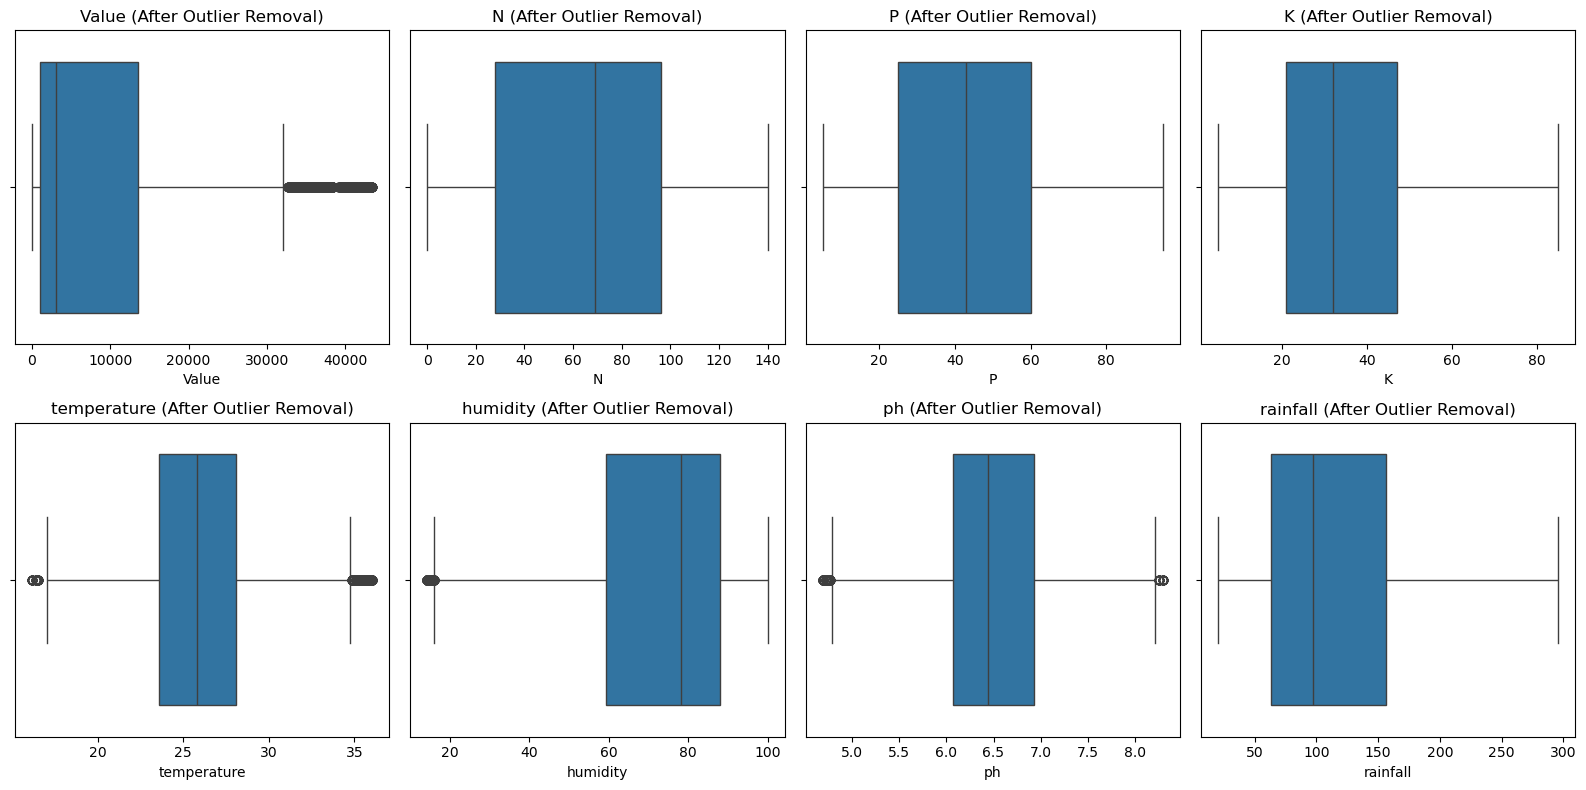

In [88]:
print("--- Outlier Analysis (After Removal) ---")

plt.figure(figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x=final_df[col])
    plt.title(f"{col} (After Outlier Removal)")

plt.tight_layout()
plt.show()


In [90]:
final_df.head()

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2748.734915
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2271.123913
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2960.979166
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2777.587400
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3251.677623


In [92]:
print(f"Crops Remaining: {final_df['Crop'].nunique()}")
print(f"List: {sorted(final_df['Crop'].unique())}")

Crops Remaining: 16
List: ['banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']


In [94]:
len(final_df)

33407

In [96]:
final_df['Crop'].value_counts()

Crop
maize         2300
lentil        2300
banana        2300
watermelon    2300
muskmelon     2300
coconut       2300
cotton        2300
jute          2300
coffee        2300
rice          2254
mango         2162
chickpea      2001
pigeonpeas    2001
orange        1794
papaya        1315
mothbeans     1180
Name: count, dtype: int64

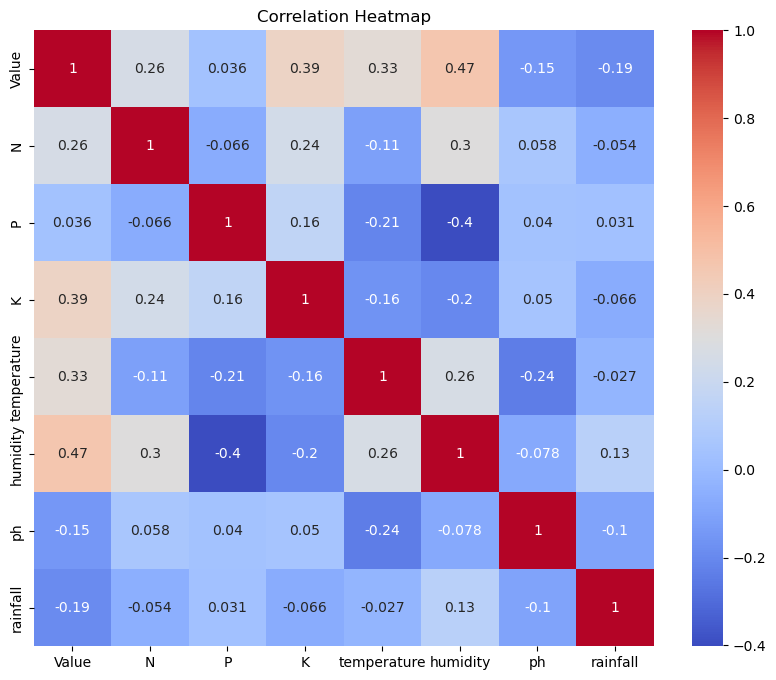

In [98]:
plt.figure(figsize=(10,8))
sns.heatmap(final_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Visualizing Data Distribution AFTER Removal...


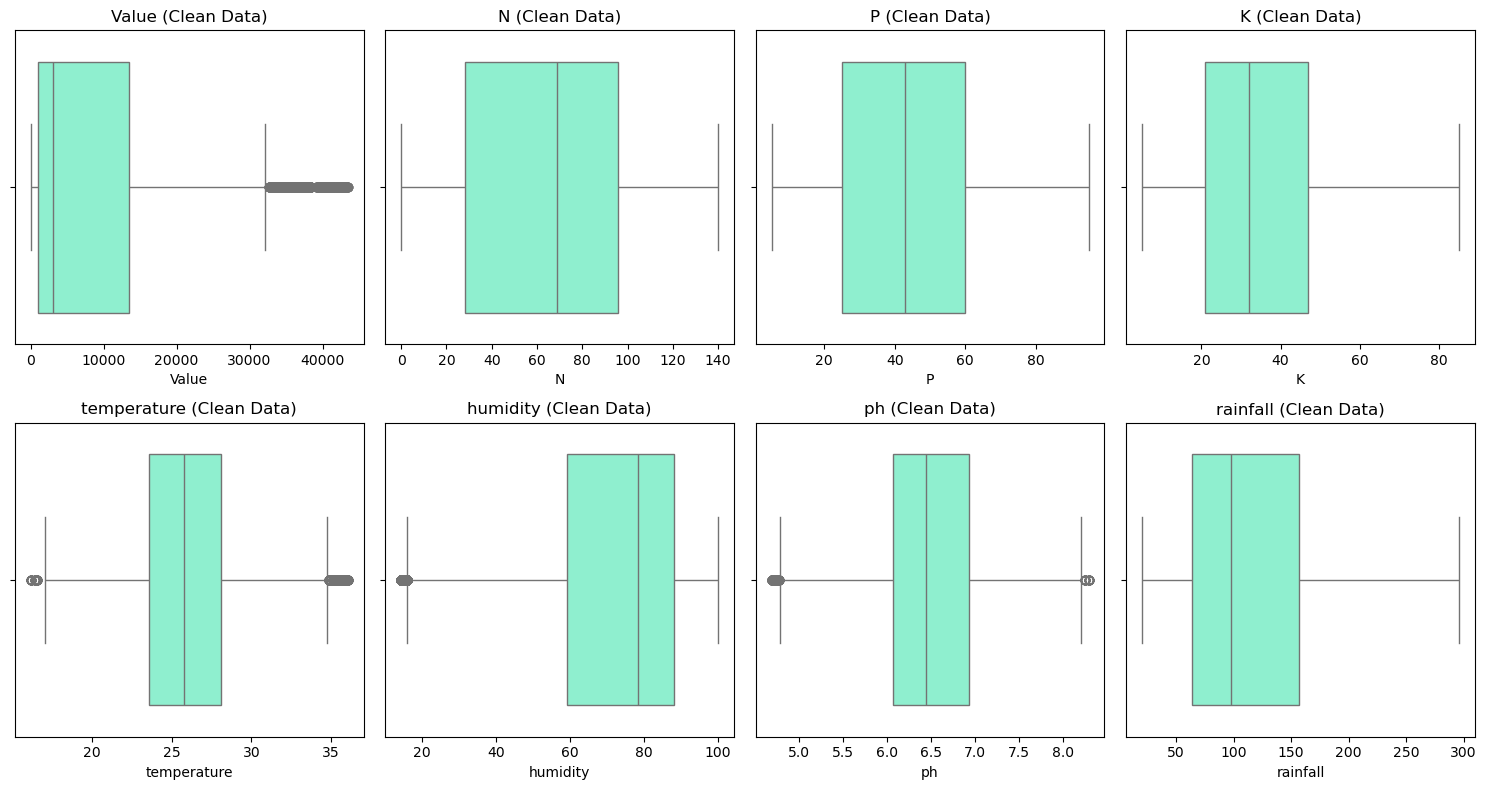

In [101]:
try:
    print("Visualizing Data Distribution AFTER Removal...")

    # Plot Clean Data
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(numeric_cols):
        plt.subplot(2, 4, i + 1)
        sns.boxplot(x=final_df[col], color='aquamarine')
        plt.title(f'{col} (Clean Data)')
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")


In [103]:
print("--- Dataset Cleaning After Removing Outliers ---")
print("Dataset Shape:", final_df.shape)
print("Missing values before cleaning:")
print(final_df.isnull().sum())
# Convert to numeric
final_df['Value'] = pd.to_numeric(final_df['Value'], errors='coerce')

# Remove rows where yield is missing
final_df = final_df.dropna(subset=['Value'])
soil_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for col in soil_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
    final_df[col] = final_df[col].fillna(final_df[col].mean())
print("Missing values after cleaning:")
print(final_df.isnull().sum())

print("Final Dataset Shape:", final_df.shape)


--- Dataset Cleaning After Removing Outliers ---
Dataset Shape: (33407, 9)
Missing values before cleaning:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64
Missing values after cleaning:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64
Final Dataset Shape: (33407, 9)


In [106]:
import numpy as np
import pandas as pd

print("--- Injecting 'Zero Yield' Scenarios (Micro-Injection) ---")

# 1️ Remove existing zero-yield rows (clean start)
if 'Value' in final_df.columns:
    original_len = len(final_df)
    final_df = final_df[final_df['Value'] > 0]
    print(f"Cleaned {original_len - len(final_df)} existing zero-yield rows to start fresh.")

# 2️ Get crop list from EXISTING Crop column
crops_list = final_df['Crop'].unique()
print(f"Generating micro-failure cases for {len(crops_list)} crops...")

# 3️ Generate ONLY 3 zero-yield rows per crop
failure_data = []

for crop in crops_list:
    # Case A: Extreme Heat
    failure_data.append({
        'N': 0, 'P': 0, 'K': 0,
        'temperature': 55, 'humidity': 20,
        'ph': 6, 'rainfall': 100,
        'Crop': crop, 'Value': 0
    })

    # Case B: Extreme Frost
    failure_data.append({
        'N': 50, 'P': 50, 'K': 50,
        'temperature': -5, 'humidity': 40,
        'ph': 6, 'rainfall': 100,
        'Crop': crop, 'Value': 0
    })

    # Case C: Severe Drought
    failure_data.append({
        'N': 50, 'P': 50, 'K': 50,
        'temperature': 30, 'humidity': 30,
        'ph': 6, 'rainfall': 0,
        'Crop': crop, 'Value': 0
    })

# 4️ Merge with original dataframe
zero_yield_df = pd.DataFrame(failure_data)
old_shape = final_df.shape
final_df = pd.concat([final_df, zero_yield_df], ignore_index=True)

print(f"✅ Added {len(zero_yield_df)} 'Zero Yield' rows (3 per crop).")
print(f"Shape Before: {old_shape} → After: {final_df.shape}")


--- Injecting 'Zero Yield' Scenarios (Micro-Injection) ---
Cleaned 49 existing zero-yield rows to start fresh.
Generating micro-failure cases for 16 crops...
✅ Added 48 'Zero Yield' rows (3 per crop).
Shape Before: (33358, 9) → After: (33406, 9)


In [108]:
final_df

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2748.734915
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2271.123913
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2960.979166
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2777.587400
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3251.677623
...,...,...,...,...,...,...,...,...,...
33401,50,50,50,-5.000000,40.000000,6.000000,100.000000,jute,0.000000
33402,50,50,50,30.000000,30.000000,6.000000,0.000000,jute,0.000000
33403,0,0,0,55.000000,20.000000,6.000000,100.000000,coffee,0.000000
33404,50,50,50,-5.000000,40.000000,6.000000,100.000000,coffee,0.000000


In [110]:
print("Final Dataset Shape:", final_df.shape)
print("Total Unique Crops:", final_df['Crop'].nunique())


Final Dataset Shape: (33406, 9)
Total Unique Crops: 16


In [112]:
print("\nRecords per Crop:")
print(final_df['Crop'].value_counts())



Records per Crop:
Crop
maize         2303
lentil        2303
banana        2303
watermelon    2303
muskmelon     2303
coconut       2303
cotton        2303
jute          2303
coffee        2303
rice          2257
mango         2165
chickpea      2004
pigeonpeas    2004
orange        1797
papaya        1318
mothbeans     1134
Name: count, dtype: int64


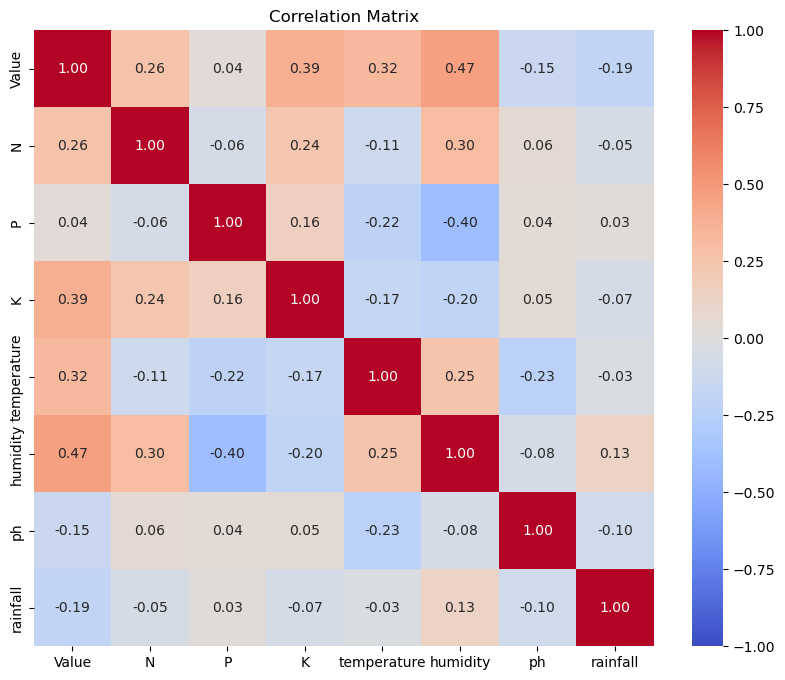

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['Value', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr_matrix = final_df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.show()


In [116]:
print("Total Rows:", len(final_df))
print("Total Crops:", final_df['Crop'].nunique())


Total Rows: 33406
Total Crops: 16


avg_yield = final_df.groupby('Crop')['Value'].mean().sort_values()
plt.figure(figsize=(12, max(6, len(avg_yield) * 0.4)))

sns.barplot(
    y=avg_yield.index,
    x=avg_yield.values
)

plt.xlabel("Average Yield")
plt.ylabel("Crop")
plt.title("Average Crop Yield")
plt.show()


In [118]:
import os

# Directory name
save_dir = "Agriyield_new_csv"

# Create directory if it does not exist
os.makedirs(save_dir, exist_ok=True)

# Save CSV file
final_df.to_csv(os.path.join(save_dir, "Final_Agri_Data.csv"), index=False)

print("✅ Clean data saved successfully in 'Agriyield_new_csv/Final_Agri_Data.csv'")


✅ Clean data saved successfully in 'Agriyield_new_csv/Final_Agri_Data.csv'
